In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sqlalchemy import create_engine

%matplotlib inline

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

In [12]:
profit_loss = pd.read_csv(
    r"C:\Users\sujit\OneDrive\Documents\financial-intelligence-system\exports\clean_profit_loss.csv"
)

balance_sheet = pd.read_csv(
    r"C:\Users\sujit\OneDrive\Documents\financial-intelligence-system\exports\clean_balance_sheet.csv"
)

cash_flow = pd.read_csv(
    r"C:\Users\sujit\OneDrive\Documents\financial-intelligence-system\exports\clean_cash_flow.csv"
)

analysis = pd.read_csv(
    r"C:\Users\sujit\OneDrive\Documents\financial-intelligence-system\exports\clean_analysis.csv"
)

In [13]:
profit_loss.head()

,id,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout,net_margin,operating_margin,interest_burden
0,61,ABB,Dec 2012,1653,1451,202.0,12.0,33,0,19,215,33.0,145,68.0,25.0,8.771930,12.220206,0.000000
1,62,ABB,Mar 2014,2276,2009,267.0,12.0,49,0,22,295,33.0,198,93.0,25.0,8.699473,11.731107,0.000000
2,63,ABB,Mar 2015,2289,1977,312.0,14.0,48,0,15,344,34.0,229,108.0,29.0,10.004369,13.630406,0.000000
3,64,ABB,Mar 2016,2614,2250,365.0,14.0,50,3,14,398,36.0,255,120.0,29.0,9.755164,13.963275,0.114767
4,65,ABB,Mar 2017,2903,2505,398.0,14.0,57,2,16,436,37.0,277,130.0,31.0,9.541853,13.709955,0.068894


In [14]:
profit_loss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1276 entries, 0 to 1275
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1276 non-null   int64  
 1   company_id         1276 non-null   object 
 2   year               1276 non-null   object 
 3   sales              1276 non-null   int64  
 4   expenses           1276 non-null   int64  
 5   operating_profit   1263 non-null   float64
 6   opm_percentage     1261 non-null   float64
 7   other_income       1276 non-null   int64  
 8   interest           1276 non-null   int64  
 9   depreciation       1276 non-null   int64  
 10  profit_before_tax  1276 non-null   int64  
 11  tax_percentage     1181 non-null   float64
 12  net_profit         1276 non-null   int64  
 13  eps                1271 non-null   float64
 14  dividend_payout    1173 non-null   float64
 15  net_margin         1275 non-null   float64
 16  operating_margin   1262 

In [15]:
profit_loss.describe()

,id,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout,net_margin,operating_margin,interest_burden
count,1276.000000,1276.000000,1276.000000,1263.000000,1261.000000,1276.000000,1276.000000,1276.000000,1276.000000,1181.000000,1276.000000,1271.000000,1173.000000,1275.000000,1262.000000,1275.000000
mean,724.192790,64366.308777,46790.302508,14621.886778,349.936558,2006.887931,6290.561912,2408.515674,7664.757837,24.279424,5737.674765,12.581432,26.496164,18.594697,31.799067,10.480390
std,379.978128,115696.774399,103593.923463,25127.504122,5819.466560,10169.442228,20425.108328,5261.460086,12978.942719,21.124646,9974.931382,2660.377640,54.087885,66.439971,28.949967,18.622393
min,61.000000,0.000000,-366.000000,-86697.000000,-57587.000000,-37775.000000,-987.000000,0.000000,-42846.000000,-99.000000,-30664.000000,-70097.000000,-999.000000,-91.593090,-170.830160,-0.797844
25%,391.750000,9830.750000,4301.750000,1825.000000,12.000000,21.000000,78.000000,184.750000,1225.000000,20.000000,954.250000,7.000000,10.000000,5.545286,14.363378,0.457275
50%,736.500000,25803.500000,12069.500000,5473.000000,21.000000,243.000000,514.000000,629.000000,3141.000000,26.000000,2336.500000,18.000000,22.000000,11.476091,22.290621,1.827393
75%,1055.250000,68264.750000,40377.500000,19312.000000,37.000000,1223.000000,4535.500000,2099.500000,9204.000000,32.000000,6797.750000,42.000000,39.000000,17.268800,38.270833,10.192490
max,1374.000000,939838.000000,870255.000000,206009.000000,47971.000000,157189.000000,284056.000000,53226.000000,104727.000000,99.000000,79941.000000,42481.000000,859.000000,947.509579,117.123001,91.385412


In [16]:
profit_loss.isnull().sum()

id                     0
company_id             0
year                   0
sales                  0
expenses               0
operating_profit      13
opm_percentage        15
other_income           0
interest               0
depreciation           0
profit_before_tax      0
tax_percentage        95
net_profit             0
eps                    5
dividend_payout      103
net_margin             1
operating_margin      14
interest_burden        1
dtype: int64

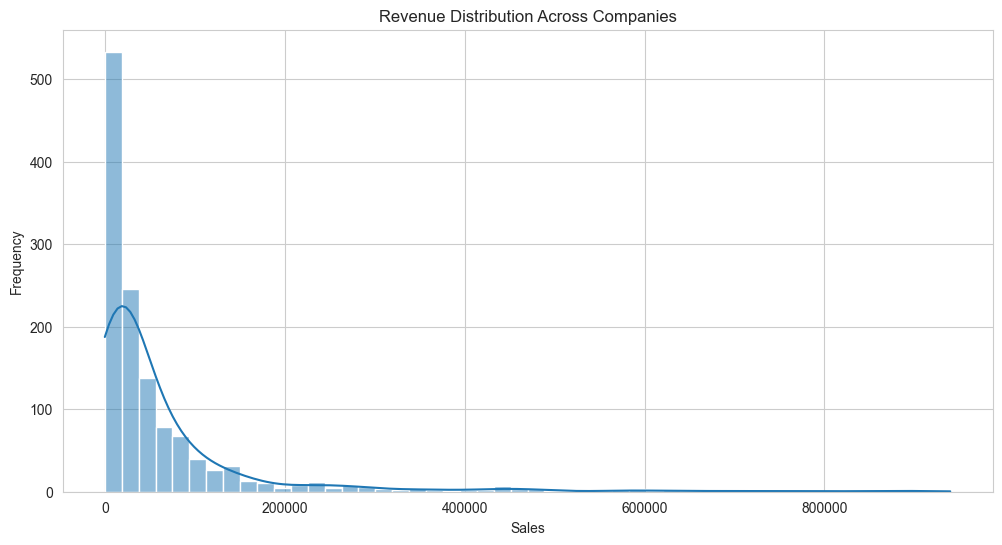

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(
    profit_loss["sales"],
    bins=50,
    kde=True
)

plt.title("Revenue Distribution Across Companies")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

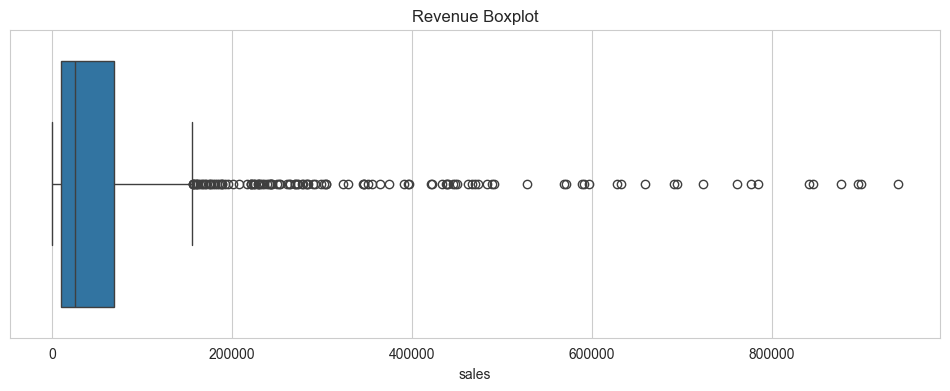

In [18]:
plt.figure(figsize=(12,4))

sns.boxplot(
    x=profit_loss["sales"]
)

plt.title("Revenue Boxplot")

plt.show()

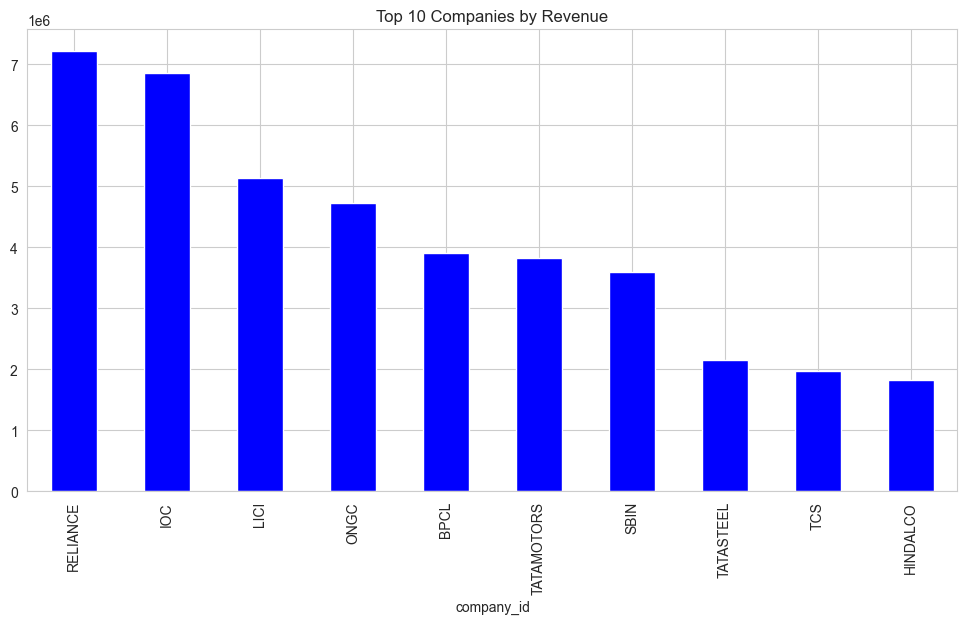

In [19]:
top_revenue = (
    profit_loss.groupby("company_id")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue.plot(
    kind="bar",
    color="blue"
)

plt.title("Top 10 Companies by Revenue")

plt.show()

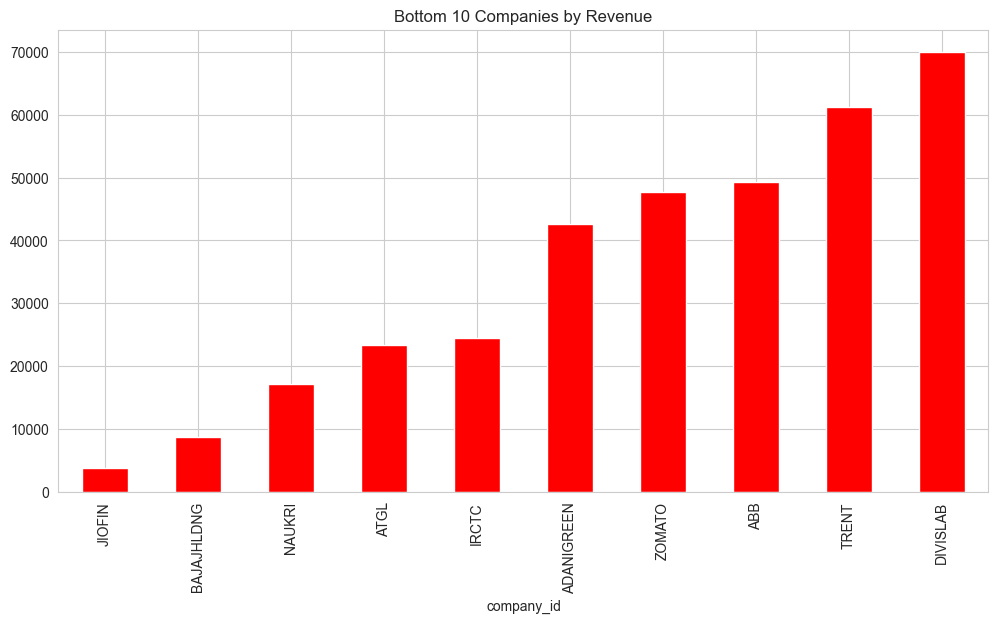

In [20]:
bottom_revenue = (
    profit_loss.groupby("company_id")["sales"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

bottom_revenue.plot(
    kind="bar",
    color="red"
)

plt.title("Bottom 10 Companies by Revenue")

plt.show()

In [21]:
profit_loss["net_margin"] = (
    profit_loss["net_profit"] /
    profit_loss["sales"]
) * 100

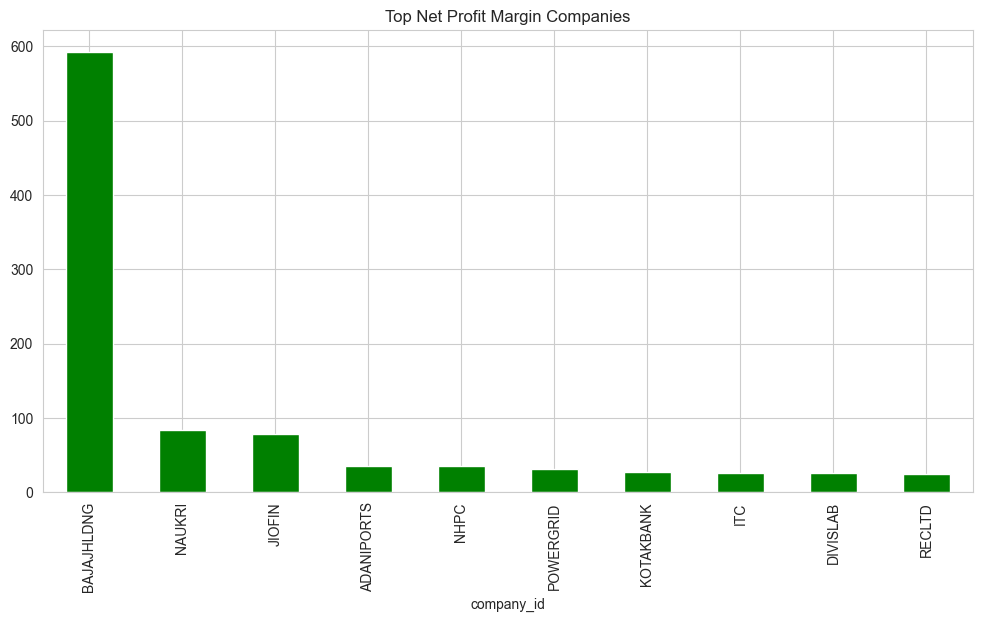

In [22]:
top_margin = (
    profit_loss.groupby("company_id")["net_margin"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_margin.plot(
    kind="bar",
    color="green"
)

plt.title("Top Net Profit Margin Companies")

plt.show()

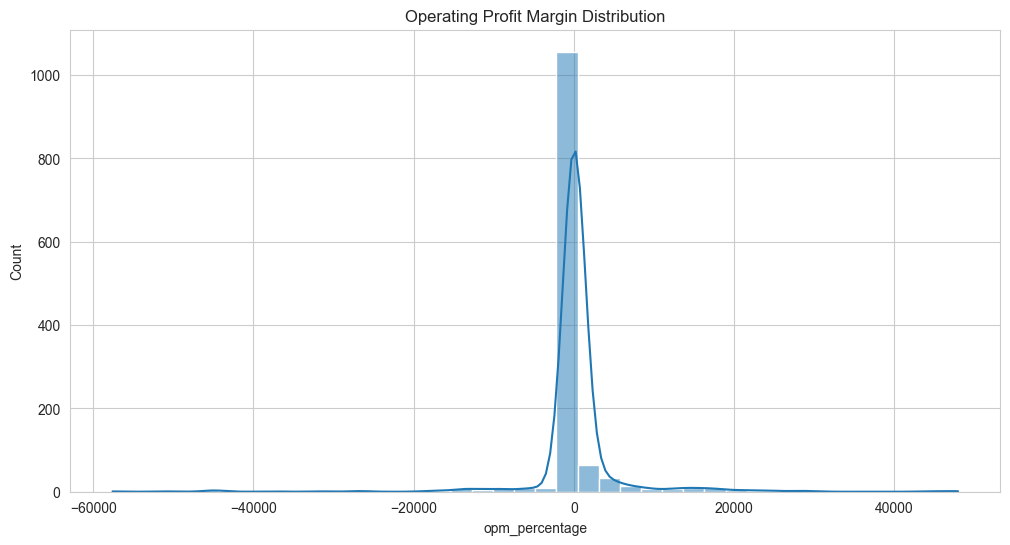

In [23]:
sns.histplot(
    profit_loss["opm_percentage"],
    bins=40,
    kde=True
)

plt.title("Operating Profit Margin Distribution")

plt.show()

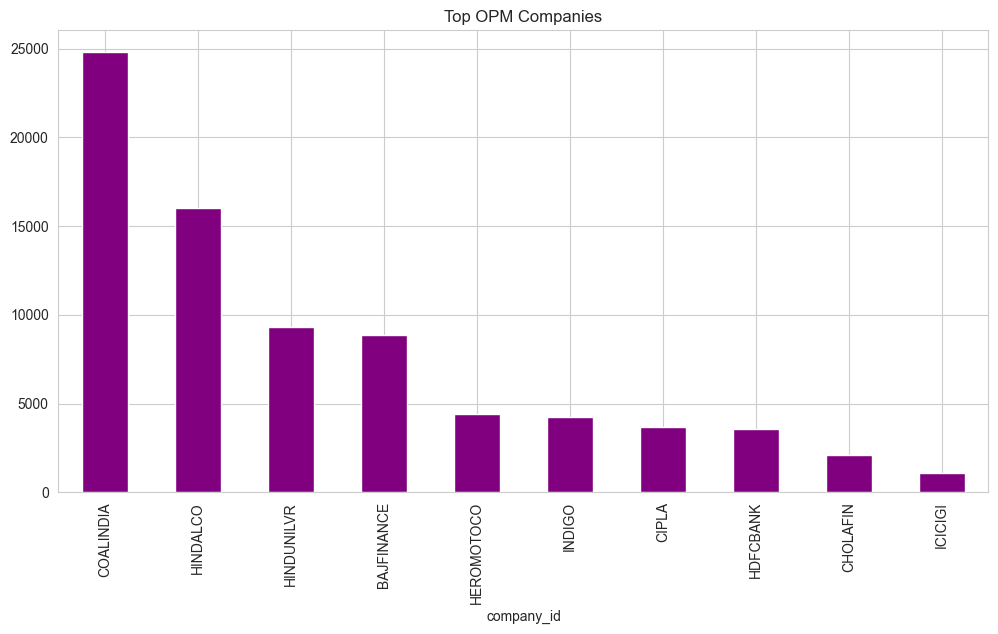

In [24]:
top_opm = (
    profit_loss.groupby("company_id")["opm_percentage"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_opm.plot(
    kind="bar",
    color="purple"
)

plt.title("Top OPM Companies")

plt.show()

In [25]:
balance_sheet["roe"] = (
    balance_sheet["reserves"] /
    balance_sheet["equity_capital"]
) * 100

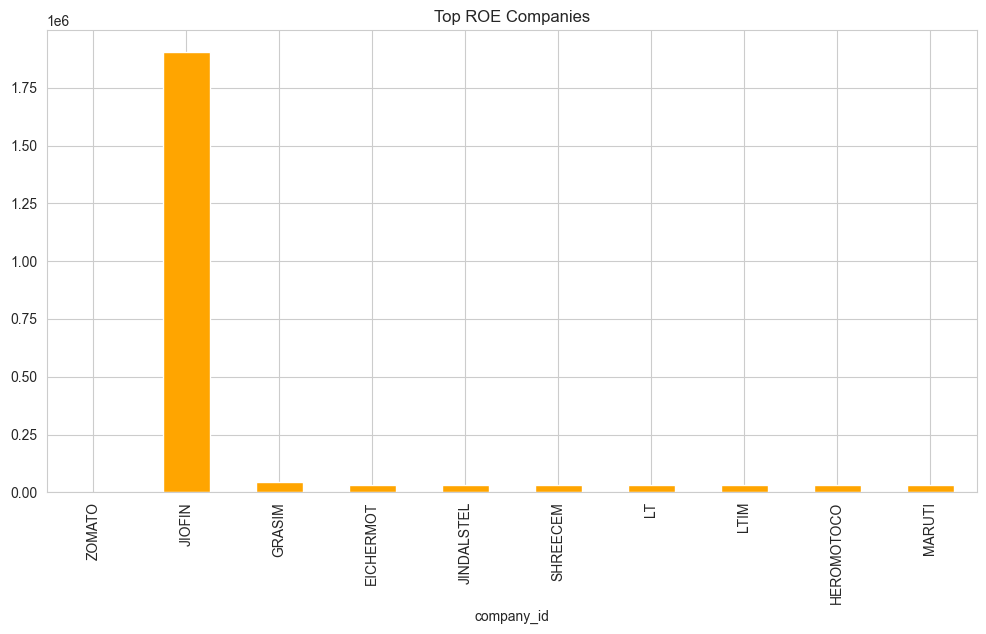

In [26]:
top_roe = (
    balance_sheet.groupby("company_id")["roe"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_roe.plot(
    kind="bar",
    color="orange"
)

plt.title("Top ROE Companies")

plt.show()

In [27]:
merged = profit_loss.merge(
    balance_sheet,
    on=["company_id", "year"],
    how="inner"
)

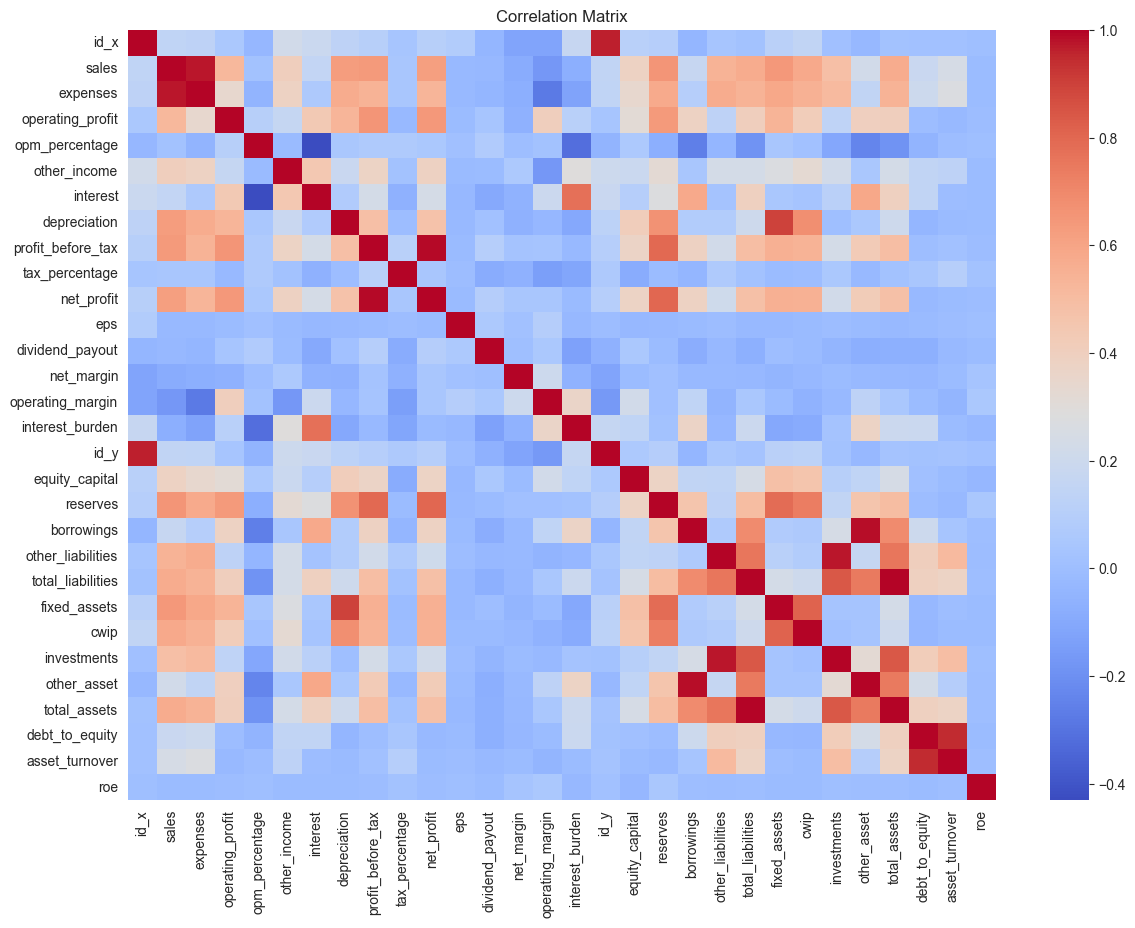

In [28]:
numeric_cols = merged.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

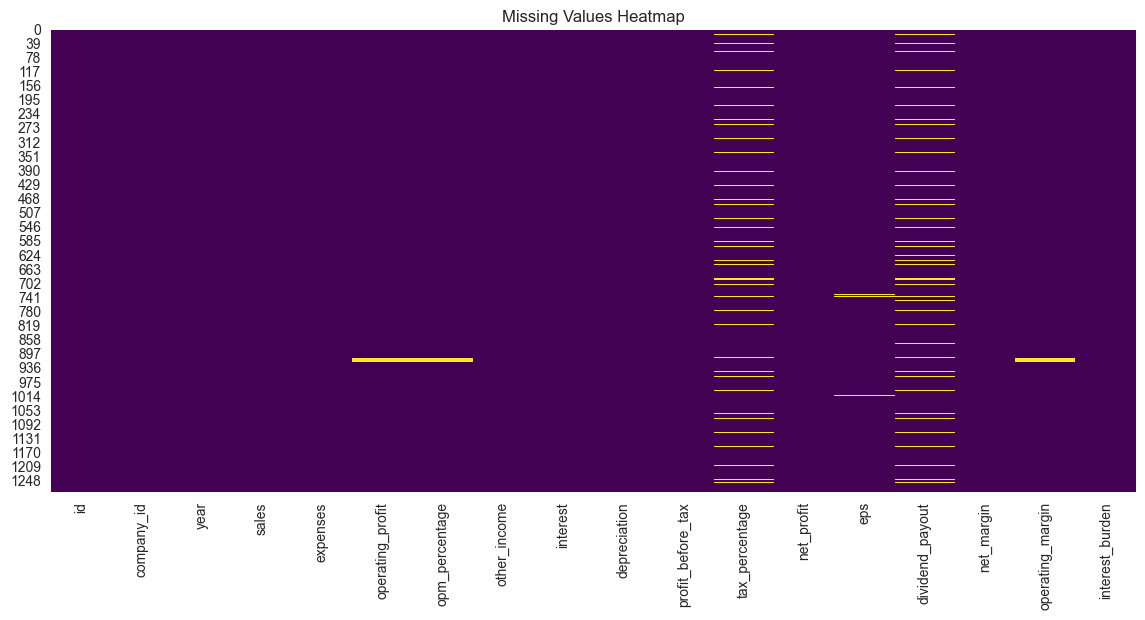

In [29]:
plt.figure(figsize=(14,6))

sns.heatmap(
    profit_loss.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

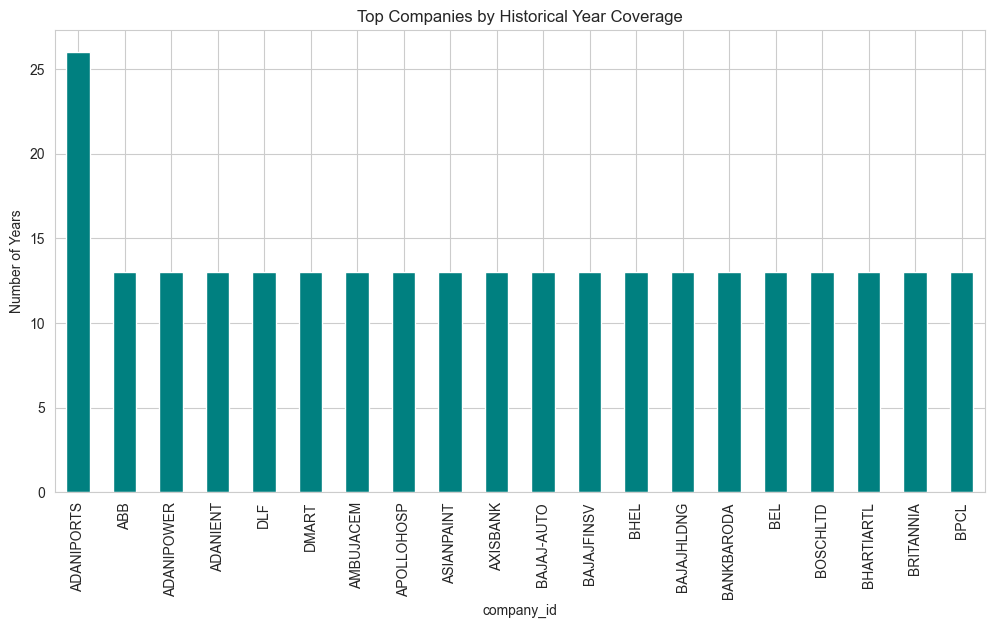

In [30]:
year_coverage = (
    profit_loss.groupby("company_id")["year"]
    .count()
    .sort_values(ascending=False)
)

year_coverage.head(20).plot(
    kind="bar",
    color="teal"
)

plt.title("Top Companies by Historical Year Coverage")

plt.ylabel("Number of Years")

plt.show()

In [31]:
sales_growth = (
    profit_loss.groupby("company_id")["sales"]
    .agg(["first", "last"])
)

sales_growth["growth_rate"] = (
    (
        sales_growth["last"] -
        sales_growth["first"]
    )
    /
    sales_growth["first"]
) * 100

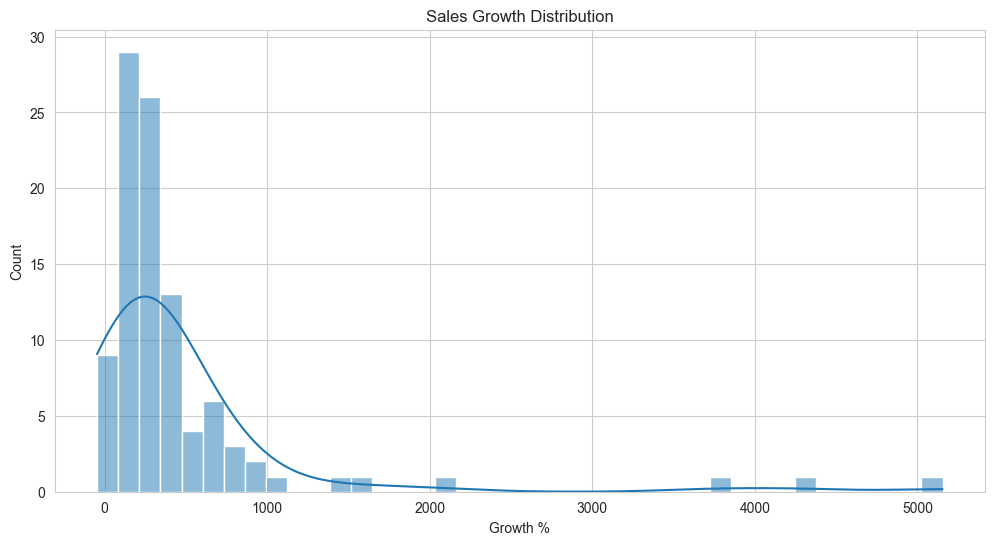

In [32]:
sns.histplot(
    sales_growth["growth_rate"],
    bins=40,
    kde=True
)

plt.title("Sales Growth Distribution")

plt.xlabel("Growth %")

plt.show()

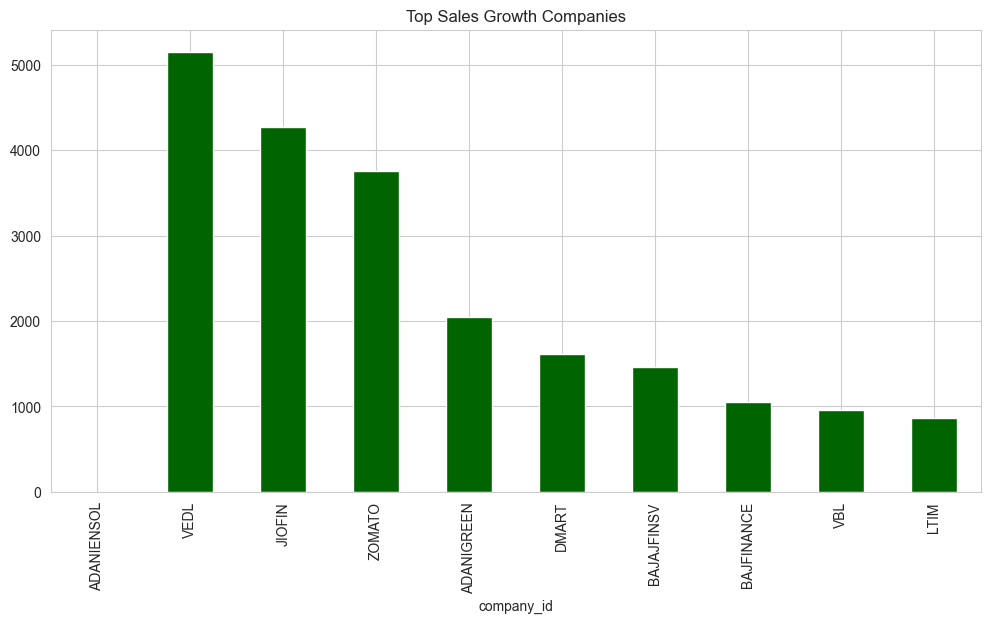

In [33]:
top_growth = (
    sales_growth["growth_rate"]
    .sort_values(ascending=False)
    .head(10)
)

top_growth.plot(
    kind="bar",
    color="darkgreen"
)

plt.title("Top Sales Growth Companies")

plt.show()

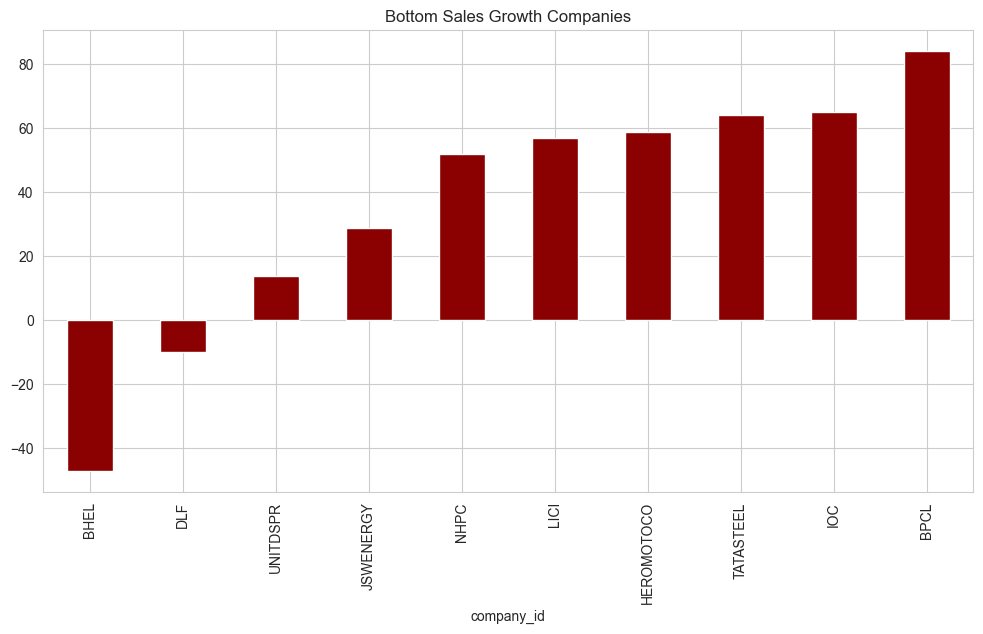

In [34]:
bottom_growth = (
    sales_growth["growth_rate"]
    .sort_values(ascending=True)
    .head(10)
)

bottom_growth.plot(
    kind="bar",
    color="darkred"
)

plt.title("Bottom Sales Growth Companies")

plt.show()

In [35]:
balance_sheet["debt_to_equity"] = (
    balance_sheet["borrowings"] /
    (
        balance_sheet["equity_capital"] +
        balance_sheet["reserves"]
    )
)

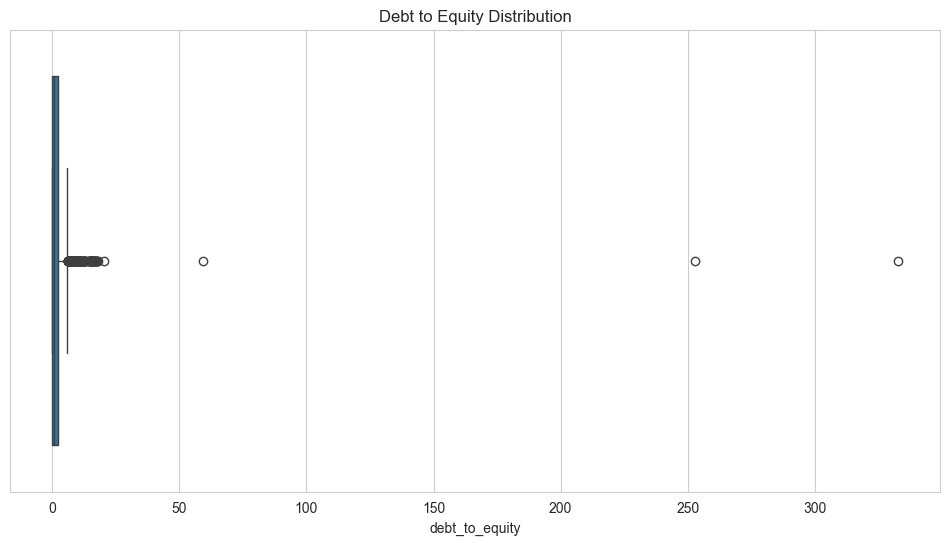

In [36]:
sns.boxplot(
    x=balance_sheet["debt_to_equity"]
)

plt.title("Debt to Equity Distribution")

plt.show()

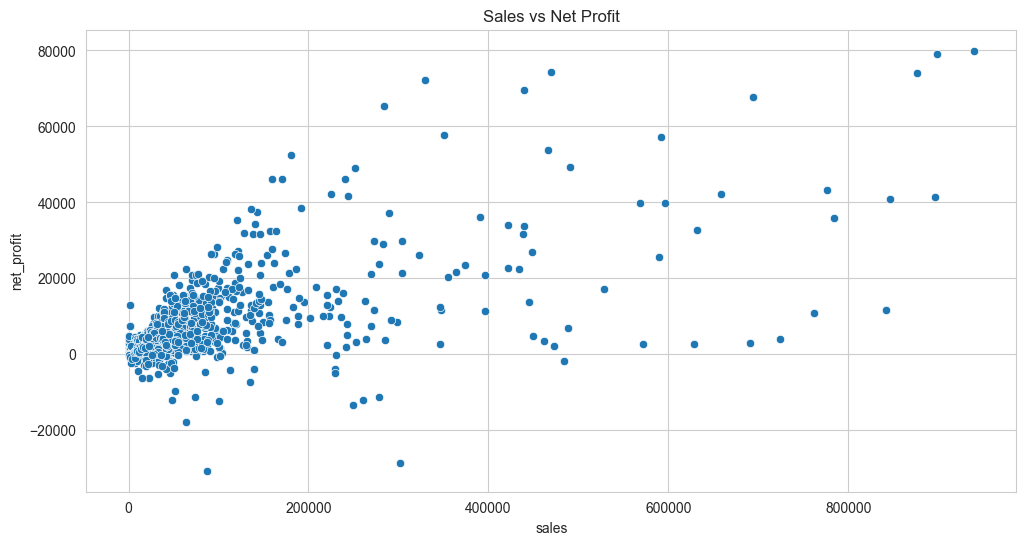

In [37]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=profit_loss,
    x="sales",
    y="net_profit"
)

plt.title("Sales vs Net Profit")

plt.show()

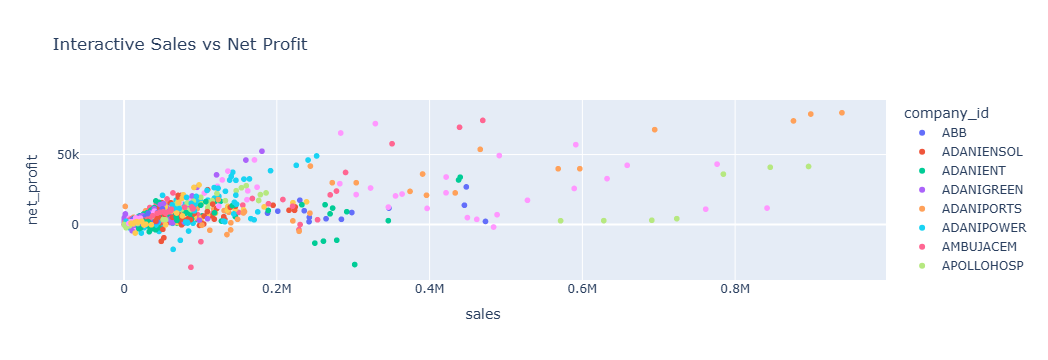

In [38]:
interactive_chart = px.scatter(
    profit_loss,
    x="sales",
    y="net_profit",
    color="company_id",
    title="Interactive Sales vs Net Profit"
)

interactive_chart.show()

In [39]:
analysis.columns

Index(['id', 'company_id', 'compounded_sales_growth',
       'compounded_profit_growth', 'stock_price_cagr', 'roe'],
      dtype='object')